# Freight Rate Prediction

EDA -> feature engineering -> split -> model comparison -> prediction (Spotter assessment)

## 1. EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)

In [2]:
train = pd.read_csv('../data/train-test.csv')
val = pd.read_csv('../data/validation.csv')
train.shape, val.shape

((48000, 14), (12000, 13))

In [3]:
train.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [4]:
val.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
0,TE-000001,Baton Rouge,Mobile,30.50134,-92.65374,31.80442,-88.25195,331.4,Flatbed,19958.0,2025-11-01,0.90402,1.86388
1,TE-000002,Savannah,Los Angeles,33.60973,-82.29994,28.56624,-116.70249,2406.2,Reefer,34114.0,2025-11-01,0.92851,1.86240
2,TE-000003,San Francisco,Raleigh,35.19670,-121.69849,35.37376,-77.47605,2846.6,Dry Van,33435.0,2025-11-01,0.88117,1.95480
3,TE-000004,Dayton,Los Angeles,39.87206,-85.62931,28.56624,-116.70249,2261.6,Dry Van,25392.0,2025-11-01,0.89156,2.14579
4,TE-000005,Memphis,San Antonio,35.56802,-89.52871,29.50969,-98.40059,800.4,Flatbed,NaN,2025-11-01,0.88308,2.22541


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


missing values

In [6]:
train.isna().sum()[train.isna().sum()>0]

weight          300
market_index    374
dtype: int64

In [7]:
val.isna().sum()[val.isna().sum()>0]

weight          165
market_index    249
dtype: int64

duplicates

In [8]:
train['load_id'].duplicated().sum(), train.duplicated().sum()

(np.int64(0), np.int64(0))

In [9]:
val['load_id'].duplicated().sum(), val.duplicated().sum()

(np.int64(0), np.int64(0))

are the empty weight rows the same as the empty market_index rows? checking before deciding how to handle it

In [10]:
overlap_train = (train['weight'].isna() & train['market_index'].isna()).sum()
overlap_train

np.int64(1)

In [11]:
overlap_val = (val['weight'].isna() & val['market_index'].isna()).sum()
overlap_val

np.int64(5)

overlap is tiny, so they're independent - not one shared root cause

negative weight? doesn't make physical sense

In [12]:
(train['weight']<0).sum(), (val['weight']<0).sum()

(np.int64(292), np.int64(145))

In [13]:
train.loc[train['weight']<0,'weight'].head(10)

68     -36559.0
204    -26670.0
206    -20003.0
225    -23981.0
376    -41397.0
446    -37215.0
495    -31214.0
641    -41023.0
806    -28320.0
1093   -25153.0
Name: weight, dtype: float64

In [14]:
train.loc[train['weight']<0,'weight'].abs().describe()

count      292.000000
mean     31724.195205
std       8262.536326
min       5000.000000
25%      25928.500000
50%      31821.500000
75%      37284.250000
max      47500.000000
Name: weight, dtype: float64

In [15]:
train.loc[train['weight']>0,'weight'].describe()

count    47408.000000
mean     31415.358674
std       7994.902979
min       5000.000000
25%      25922.000000
50%      31493.500000
75%      37063.000000
max      47500.000000
Name: weight, dtype: float64

range matches the positive weights almost exactly, so this is a sign error at input, not a real outlier. fixing with abs() later

checking rate distribution & rate per mile

In [16]:
train['rate_per_mile'] = train['posted_rate'] / train['distance']

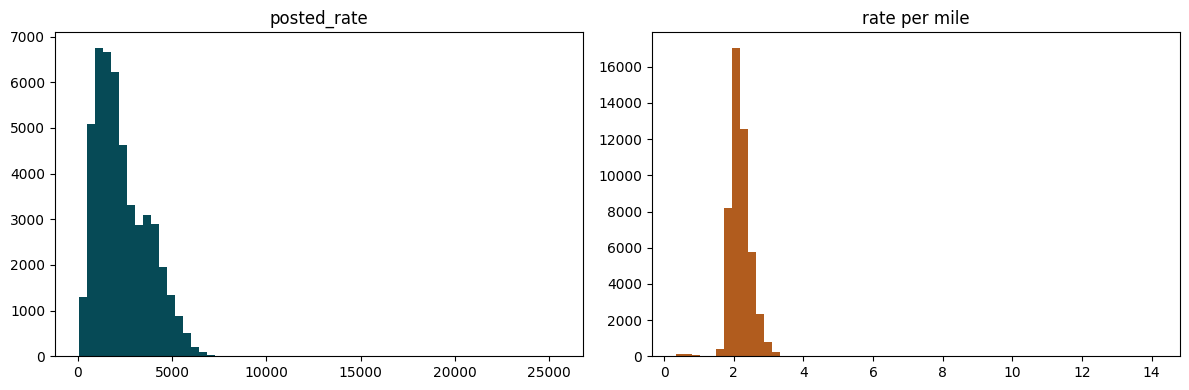

In [17]:
fig, ax = plt.subplots(1,2,figsize=(12,4))
ax[0].hist(train['posted_rate'], bins=60, color='#064A56')
ax[0].set_title('posted_rate')
ax[1].hist(train['rate_per_mile'], bins=60, color='#B15C1E')
ax[1].set_title('rate per mile')
plt.tight_layout()
plt.show()

In [18]:
train[['posted_rate','rate_per_mile']].describe()

,posted_rate,rate_per_mile
count,48000.000000,48000.000000
mean,2373.980682,2.215347
std,1486.493245,0.583887
min,57.220000,0.333709
25%,1251.555000,1.986974
50%,2030.760000,2.145348
75%,3330.750000,2.342696
max,25533.000000,14.125294


correlation with target (weight already abs'd so the sign error doesn't skew this)

In [19]:
train['weight_abs'] = train['weight'].abs()

In [20]:
corr = train[['distance','weight_abs','market_index','quote_signal','posted_rate']].corr()
corr['posted_rate'].sort_values(ascending=False)

posted_rate     1.000000
distance        0.908519
weight_abs      0.041343
market_index    0.034165
quote_signal   -0.039858
Name: posted_rate, dtype: float64

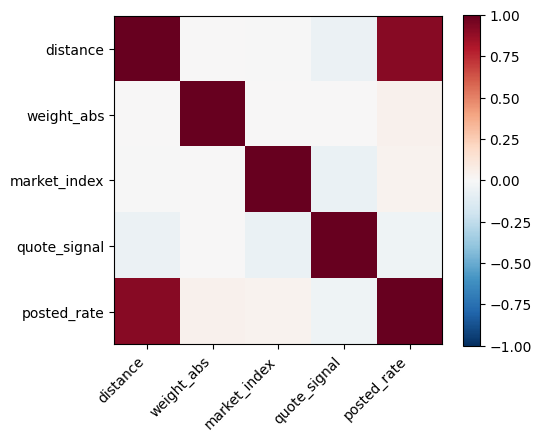

In [21]:
fig, ax = plt.subplots(figsize=(5.5,4.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
plt.colorbar(im)
plt.tight_layout()
plt.show()

distance is dominant (~0.9). the rest have small linear correlation but that doesn't mean they're useless - could be nonlinear, let the tree model figure it out

cities that show up in validation but never appear in train - risky if used for one-hot encoding

In [22]:
train_cities = set(train['pickup']) | set(train['delivery'])
val_cities = set(val['pickup']) | set(val['delivery'])

In [23]:
unseen_cities = val_cities - train_cities
len(unseen_cities)

8

In [24]:
sorted(unseen_cities)

['Allentown',
 'Charlotte',
 'Chicago',
 'Jackson',
 'Knoxville',
 'Laredo',
 'Norfolk',
 'San Diego']

8 new cities. can't use city name directly as a category, the encoder would be blind to them. checking lat/lon instead, might work as a replacement

In [25]:
pickup_coords = train.groupby('pickup')[['pickup_lat','pickup_lon']].nunique()
(pickup_coords>1).any(axis=1).sum()

np.int64(0)

In [26]:
delivery_coords = train.groupby('delivery')[['delivery_lat','delivery_lon']].nunique()
(delivery_coords>1).any(axis=1).sum()

np.int64(0)

all zero, so every city has one fixed lat/lon. safe to use in place of city name

train vs validation dates - important for deciding the split strategy

In [27]:
train['date'] = pd.to_datetime(train['date'])
val['date'] = pd.to_datetime(val['date'])

In [28]:
train['date'].min(), train['date'].max()

(Timestamp('2025-01-01 00:00:00'), Timestamp('2025-10-31 00:00:00'))

In [29]:
val['date'].min(), val['date'].max()

(Timestamp('2025-11-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

validation starts exactly one day after train ends. this is forward forecasting, not a random sample, so the internal holdout also needs to come from the tail end of the dates, not a random split

**EDA summary**
- no duplicates
- missing values only in weight & market_index, independent of each other
- negative weight = sign error → abs()
- distance is the dominant feature
- train (Jan-Oct) < validation (Nov-Dec) → time-based split is a must
- 8 new cities in validation → use lat/lon instead of city name
- rate_per_mile has some extreme values, checking further during modeling

## 2. Feature Engineering

fix the sign error + set up medians for imputation (median from train only, so val doesn't leak in)

In [30]:
def clean_base(df):
    df = df.copy()
    df['weight'] = df['weight'].abs()
    return df

train_clean = clean_base(train)
val_clean = clean_base(val)

In [31]:
weight_median = train_clean['weight'].median()
market_index_median = train_clean['market_index'].median()
weight_median, market_index_median

(np.float64(31496.0), np.float64(1.0558))

In [32]:
for df in [train_clean, val_clean]:
    df['weight_was_missing'] = df['weight'].isna().astype(int)
    df['market_index_was_missing'] = df['market_index'].isna().astype(int)
    df['weight'] = df['weight'].fillna(weight_median)
    df['market_index'] = df['market_index'].fillna(market_index_median)

In [33]:
train_clean[['weight','market_index']].isna().sum()

weight          0
market_index    0
dtype: int64

date features - just month & day_of_week. tried day_of_year sin/cos before and it didn't help (data isn't dense enough for that precise a signal), so keeping it simple

In [34]:
def add_date_features(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['month'] = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.dayofweek
    return df

train_clean = add_date_features(train_clean)
val_clean = add_date_features(val_clean)

In [35]:
train_clean[['date','month','day_of_week']].head()

,date,month,day_of_week
0,2025-01-01,1,2
1,2025-01-01,1,2
2,2025-01-01,1,2
3,2025-01-01,1,2
4,2025-01-01,1,2


equipment: 3 fixed categories, present in both files, safe to one-hot encode

In [36]:
sorted(train_clean['equipment'].unique()), sorted(val_clean['equipment'].unique())

(['Dry Van', 'Flatbed', 'Reefer'], ['Dry Van', 'Flatbed', 'Reefer'])

In [37]:
train_encoded = pd.get_dummies(train_clean, columns=['equipment'], prefix='equip')
val_encoded = pd.get_dummies(val_clean, columns=['equipment'], prefix='equip')
equip_cols = [c for c in train_encoded.columns if c.startswith('equip_')]
equip_cols

['equip_Dry Van', 'equip_Flatbed', 'equip_Reefer']

not using city names, already explained in EDA - going with lat/lon instead

final feature list

In [38]:
feature_cols = (
    ['distance','weight','market_index','quote_signal',
     'pickup_lat','pickup_lon','delivery_lat','delivery_lon',
     'month','day_of_week','weight_was_missing','market_index_was_missing']
    + equip_cols
)
target_col = 'posted_rate'
len(feature_cols)

15

In [39]:
feature_cols

['distance',
 'weight',
 'market_index',
 'quote_signal',
 'pickup_lat',
 'pickup_lon',
 'delivery_lat',
 'delivery_lon',
 'month',
 'day_of_week',
 'weight_was_missing',
 'market_index_was_missing',
 'equip_Dry Van',
 'equip_Flatbed',
 'equip_Reefer']

## 3. Split

random split doesn't fit here - validation is the future (Nov-Dec), not a random sample from the same period. if I shuffle it, the model could 'peek' at neighboring dates during testing, making accuracy look better than it really is. holdout comes from the tail end of train_test.csv instead

In [40]:
SPLIT_DATE = '2025-09-15'
is_holdout = train_encoded['date'] >= SPLIT_DATE

In [41]:
train_split = train_encoded.loc[~is_holdout].reset_index(drop=True)
holdout_split = train_encoded.loc[is_holdout].reset_index(drop=True)
len(train_split), len(holdout_split)

(40706, 7294)

In [42]:
train_split['date'].min(), train_split['date'].max()

(Timestamp('2025-01-01 00:00:00'), Timestamp('2025-09-14 00:00:00'))

In [43]:
holdout_split['date'].min(), holdout_split['date'].max()

(Timestamp('2025-09-15 00:00:00'), Timestamp('2025-10-31 00:00:00'))

In [44]:
X_train = train_split[feature_cols]
y_train = train_split[target_col]
X_holdout = holdout_split[feature_cols]
y_holdout = holdout_split[target_col]

In [45]:
X_submission = val_encoded[feature_cols]
submission_ids = val_encoded['load_id'].reset_index(drop=True)
X_train.shape, X_holdout.shape, X_submission.shape

((40706, 15), (7294, 15), (12000, 15))

## 4. Training

comparing lightgbm vs xgboost on default settings first, exact same conditions (identical data/features/split)

In [46]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [47]:
lgbm_baseline = LGBMRegressor(random_state=42, verbosity=-1)
lgbm_baseline.fit(X_train, y_train)

LGBMRegressor(random_state=42, verbosity=-1)

In [48]:
pred_lgbm = lgbm_baseline.predict(X_holdout)

In [49]:
xgb_baseline = XGBRegressor(random_state=42, verbosity=0)
xgb_baseline.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [50]:
pred_xgb = xgb_baseline.predict(X_holdout)

In [51]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mape = (np.abs((y_true - y_pred) / y_true)).mean() * 100
    print(f"{name:10s} -> MAE: {mae:7.2f}   RMSE: {rmse:7.2f}   MAPE: {mape:5.2f}%")
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

In [52]:
results = [evaluate(y_holdout, pred_lgbm, 'LightGBM'), evaluate(y_holdout, pred_xgb, 'XGBoost')]
results_df = pd.DataFrame(results)
results_df

LightGBM   -> MAE:  142.66   RMSE:  609.45   MAPE:  6.38%
XGBoost    -> MAE:  239.35   RMSE:  736.88   MAPE: 10.99%


,model,MAE,RMSE,MAPE
0,LightGBM,142.656547,609.452170,6.377612
1,XGBoost,239.349934,736.877152,10.991723


lightgbm wins, going with this one

In [53]:
best_row = results_df.loc[results_df['MAE'].idxmin()]
best_model_name = best_row['model']
best_model = lgbm_baseline if best_model_name == 'LightGBM' else xgb_baseline
best_row

model      LightGBM
MAE      142.656547
RMSE      609.45217
MAPE       6.377612
Name: 0, dtype: object

RMSE is way bigger than MAE (>4x) - sign that a small chunk of predictions are way off. trying a few standard approaches to reduce the outlier effect on training before giving up and calling it a limitation

In [54]:
def eval_row(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mape = (np.abs((y_true - y_pred) / y_true)).mean() * 100
    return {'pendekatan': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

comparison = [eval_row(y_holdout, pred_lgbm, 'Baseline (L2/default)')]

try 1: log-transform target

In [55]:
y_train_log = np.log1p(y_train)
model_log = LGBMRegressor(random_state=42, verbosity=-1)
model_log.fit(X_train, y_train_log)
pred_log = np.expm1(model_log.predict(X_holdout))
comparison.append(eval_row(y_holdout, pred_log, 'Log-transform target'))

try 2: L1 objective (more outlier-resistant than the default L2)

In [56]:
model_l1 = LGBMRegressor(random_state=42, verbosity=-1, objective='regression_l1',
                          n_estimators=300, learning_rate=0.05)
model_l1.fit(X_train, y_train)
pred_l1 = model_l1.predict(X_holdout)
comparison.append(eval_row(y_holdout, pred_l1, 'L1 objective (tuned)'))

try 3: huber loss

In [57]:
model_huber = LGBMRegressor(random_state=42, verbosity=-1, objective='huber', alpha=300)
model_huber.fit(X_train, y_train)
pred_huber = model_huber.predict(X_holdout)
comparison.append(eval_row(y_holdout, pred_huber, 'Huber loss (delta=300)'))

In [58]:
pd.DataFrame(comparison)

,pendekatan,MAE,RMSE,MAPE
0,Baseline (L2/default),142.656547,609.452170,6.377612
1,Log-transform target,115.202890,603.394545,5.215448
2,L1 objective (tuned),102.271480,598.979440,4.661689
3,Huber loss (delta=300),118.922050,611.946591,5.184681


L1 objective wins by a good margin on MAE & MAPE. but RMSE barely moves across every approach - switching the loss function doesn't do much for RMSE. so it's probably not about how the model is trained, the outliers themselves just can't be explained by the features I have. let me prove that before concluding anything

checking: do rows with extreme rate_per_mile (>$5/mi) actually look different feature-wise from normal rows?

In [59]:
train_full_check = train_encoded.copy()
train_full_check['rate_per_mile'] = train_full_check['posted_rate'] / train_full_check['distance']
extreme = train_full_check[train_full_check['rate_per_mile'] > 5]
normal = train_full_check[train_full_check['rate_per_mile'] <= 5]
len(extreme), len(extreme)/len(train_full_check)*100

(317, 0.6604166666666667)

In [60]:
compare_cols = ['distance','weight','market_index','quote_signal']
summary = pd.DataFrame({'mean_extreme': extreme[compare_cols].mean(), 'mean_normal': normal[compare_cols].mean()})
summary['selisih_%'] = (summary['mean_extreme']-summary['mean_normal'])/summary['mean_normal']*100
summary

,mean_extreme,mean_normal,selisih_%
distance,1023.109148,1136.606208,-9.985610
weight,31578.104101,31416.675335,0.513831
market_index,1.079788,1.083194,-0.314475
quote_signal,2.069731,2.062420,0.354530


In [61]:
extreme['equip_Dry Van'].mean(), normal['equip_Dry Van'].mean()

(np.float64(0.5646687697160884), np.float64(0.5667218924983747))

averages are nearly identical between extreme and normal rows. nothing distinguishes these rows feature-wise. so this really is noise, similar to the negative weight case - not a pattern the model could ever learn

In [62]:
best_model_name = 'LightGBM (L1 objective)'
best_model = model_l1

def make_final_model():
    return LGBMRegressor(random_state=42, verbosity=-1, objective='regression_l1',
                          n_estimators=300, learning_rate=0.05)

In [63]:
mean_absolute_error(y_holdout, pred_l1), mean_squared_error(y_holdout, pred_l1)**0.5

(102.27147951644307, 598.9794404406615)

## 5. Further Validation

feature importance of the winning model

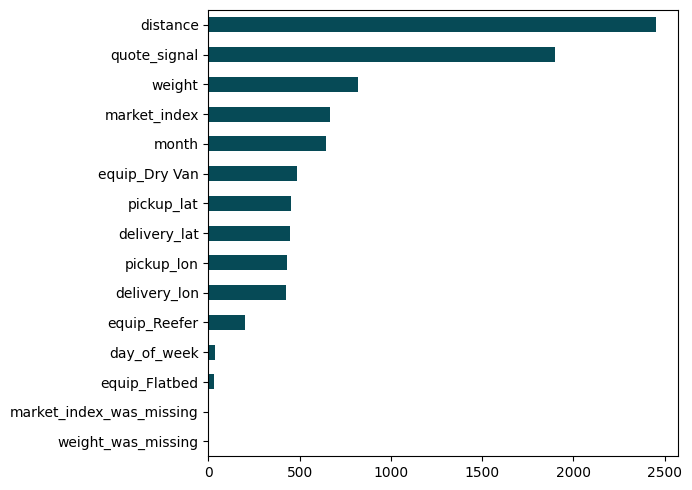

In [64]:
importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,5))
importances.plot(kind='barh', ax=ax, color='#064A56')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [65]:
importances

distance                    2451
quote_signal                1902
weight                       821
market_index                 665
month                        645
equip_Dry Van                486
pickup_lat                   454
delivery_lat                 446
pickup_lon                   433
delivery_lon                 425
equip_Reefer                 202
day_of_week                   37
equip_Flatbed                 29
market_index_was_missing       4
weight_was_missing             0
dtype: int32

distance & quote_signal are the biggest, matches the correlation findings from EDA

checking residuals - want to make sure the model isn't systematically biased in some range

In [66]:
residuals = y_holdout.values - pred_l1

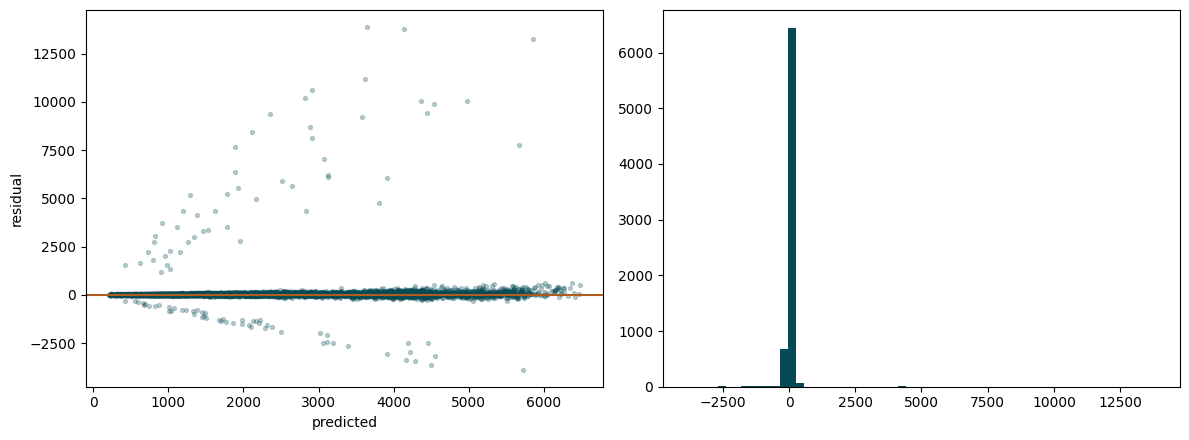

In [67]:
fig, axes = plt.subplots(1,2,figsize=(12,4.5))
axes[0].scatter(pred_l1, residuals, alpha=0.25, s=8, color='#064A56')
axes[0].axhline(0, color='#B15C1E', linewidth=1.5)
axes[0].set_xlabel('predicted'); axes[0].set_ylabel('residual')
axes[1].hist(residuals, bins=60, color='#064A56')
plt.tight_layout()
plt.show()

In [68]:
residuals.mean(), residuals.std()

(np.float64(61.78537221057918), np.float64(595.7843048045224))

residual mean is 61.79, std 595.78. honestly this isn't quite zero - compared to the MAE (102), that's a decent chunk (~60%). but there's a technical reason, not a bug: the L1 objective trains the model to predict the median, while posted_rate's distribution is right-skewed (mean 2374 > median 2031, because of the long-tail outliers covered earlier). so the model tends to slightly under-predict on average - that's an expected trade-off from picking L1 to fight the outliers, not a sign something's wrong. if the goal is a sharper median, this is already solid; if zero bias is the priority, the objective would need rethinking.

## 6. Final Predictions & December Chart

retraining on all available data (train+holdout combined) before predicting on validation.csv - holdout was only there to pick & measure the model, once that's decided there's no reason to keep holding it back

In [69]:
X_full = train_encoded[feature_cols]
y_full = train_encoded[target_col]

In [70]:
final_model = make_final_model()
final_model.fit(X_full, y_full)

LGBMRegressor(learning_rate=0.05, n_estimators=300, objective='regression_l1',
              random_state=42, verbosity=-1)

predicting on validation.csv

In [71]:
pred_submission = final_model.predict(X_submission)

In [72]:
val_template = pd.read_csv('../input/validation-predictions-template.csv')
pred_map = dict(zip(submission_ids, pred_submission))
validation_predictions = val_template.copy()
validation_predictions['predicted_rate'] = validation_predictions['load_id'].map(pred_map)
len(validation_predictions)

12000

In [73]:
validation_predictions['predicted_rate'].isna().sum(), (validation_predictions['predicted_rate'] <= 0).any()

(np.int64(0), np.False_)

In [74]:
validation_predictions.head()

,load_id,predicted_rate
0,TE-000001,833.761413
1,TE-000002,5127.273935
2,TE-000003,5311.274115
3,TE-000004,4185.985750
4,TE-000005,1773.522608


In [75]:
validation_predictions.to_csv('../outputs/result-validation-predictions.csv', index=False)

december_chart_inputs.csv (given input, 31 rows, one row per December date, every column fixed except date) - market_index/quote_signal aren't route-specific so they're not meaningful per-route in this file; using the daily average from validation.csv instead, which already has real values for Nov-Dec

In [76]:
dec = pd.read_csv('../input/december-chart-inputs.csv')
dec['date_parsed'] = pd.to_datetime(dec['date'])
# drop market_index/quote_signal if the input file already has them - they'll be replaced
# below with the real Dec daily averages from validation.csv (same as before)
dec = dec.drop(columns=[c for c in ['market_index','quote_signal'] if c in dec.columns])

In [77]:
dec_mask = (val_clean['date'] >= '2025-12-01') & (val_clean['date'] <= '2025-12-31')
daily_avg = val_clean.loc[dec_mask].groupby('date')[['market_index','quote_signal']].mean()
daily_avg.head()

,market_index,quote_signal
date,,
2025-12-01,0.839271,2.052023
2025-12-02,0.917931,2.034115
2025-12-03,0.995222,2.053293
2025-12-04,1.024650,2.065683
2025-12-05,0.976865,2.047368


In [78]:
dec = dec.merge(daily_avg, left_on='date_parsed', right_index=True, how='left')
len(dec)

31

In [79]:
dec[['market_index','quote_signal']].isna().sum()

market_index    0
quote_signal    0
dtype: int64

lexington & fort wayne lat/lon pulled from the real data (consistent per city), not guessed

In [80]:
lex_coords = train_clean.loc[train_clean['pickup']=='Lexington', ['pickup_lat','pickup_lon']].iloc[0]
lex_coords

pickup_lat    36.99152
pickup_lon   -84.99876
Name: 28, dtype: float64

In [81]:
fw_coords = train_clean.loc[train_clean['delivery']=='Fort Wayne', ['delivery_lat','delivery_lon']]
if len(fw_coords)==0:
    fw_coords = val_clean.loc[val_clean['delivery']=='Fort Wayne', ['delivery_lat','delivery_lon']]
fw_coords = fw_coords.iloc[0]
fw_coords

delivery_lat    41.31561
delivery_lon   -85.36206
Name: 24, dtype: float64

In [82]:
dec_feat = pd.DataFrame(index=dec.index)
dec_feat['distance'] = dec['distance'].astype(float)
dec_feat['weight'] = dec['weight'].astype(float)
dec_feat['market_index'] = dec['market_index']
dec_feat['quote_signal'] = dec['quote_signal']
dec_feat['pickup_lat'] = lex_coords['pickup_lat']
dec_feat['pickup_lon'] = lex_coords['pickup_lon']
dec_feat['delivery_lat'] = fw_coords['delivery_lat']
dec_feat['delivery_lon'] = fw_coords['delivery_lon']
dec_feat['month'] = dec['date_parsed'].dt.month
dec_feat['day_of_week'] = dec['date_parsed'].dt.dayofweek
dec_feat['weight_was_missing'] = 0
dec_feat['market_index_was_missing'] = 0
for col in equip_cols:
    dec_feat[col] = 1 if col == 'equip_Dry Van' else 0
dec_feat = dec_feat[feature_cols]
dec_feat.head()

,distance,weight,market_index,quote_signal,pickup_lat,pickup_lon,delivery_lat,delivery_lon,month,day_of_week,weight_was_missing,market_index_was_missing,equip_Dry Van,equip_Flatbed,equip_Reefer
0,360.0,32000.0,0.839271,2.052023,36.99152,-84.99876,41.31561,-85.36206,12,0,0,0,1,0,0
1,360.0,32000.0,0.917931,2.034115,36.99152,-84.99876,41.31561,-85.36206,12,1,0,0,1,0,0
2,360.0,32000.0,0.995222,2.053293,36.99152,-84.99876,41.31561,-85.36206,12,2,0,0,1,0,0
3,360.0,32000.0,1.024650,2.065683,36.99152,-84.99876,41.31561,-85.36206,12,3,0,0,1,0,0
4,360.0,32000.0,0.976865,2.047368,36.99152,-84.99876,41.31561,-85.36206,12,4,0,0,1,0,0


In [83]:
dec['predicted_rate'] = final_model.predict(dec_feat)
december_output = dec[['pickup','delivery','distance','equipment','weight','date','predicted_rate']]
december_output.head()

,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,12/1/2025,818.117112
1,Lexington,Fort Wayne,360,Dry Van,32000,12/2/2025,826.595755
2,Lexington,Fort Wayne,360,Dry Van,32000,12/3/2025,834.601477
3,Lexington,Fort Wayne,360,Dry Van,32000,12/4/2025,836.346455
4,Lexington,Fort Wayne,360,Dry Van,32000,12/5/2025,832.704909


In [84]:
december_output.to_csv('../outputs/result-december-chart-inputs.csv', index=False)

quick check on how flat this actually is before running score.py

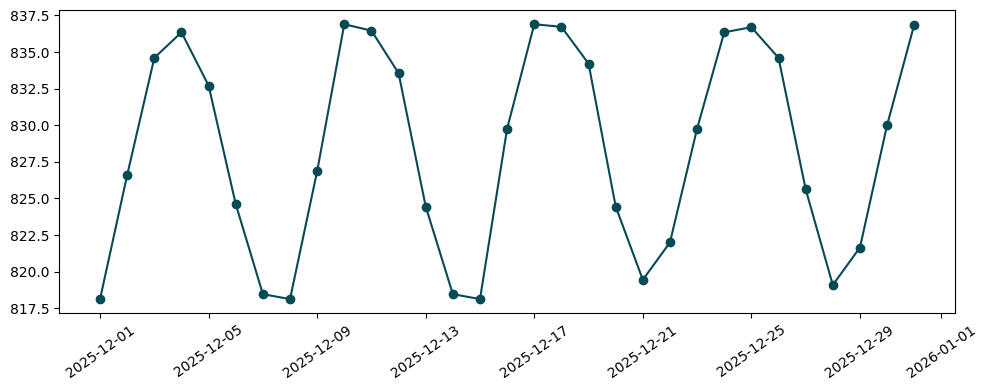

In [85]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(pd.to_datetime(december_output['date']), december_output['predicted_rate'], marker='o', color='#064A56')
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

In [86]:
spread = december_output['predicted_rate'].max() - december_output['predicted_rate'].min()
december_output['predicted_rate'].min(), december_output['predicted_rate'].max(), spread

(np.float64(818.1171124163183),
 np.float64(836.8979721294346),
 np.float64(18.780859713116342))

range is genuinely narrow (~$19) but not perfectly flat like the earlier version. the lexington-fort wayne route only has ~30 historical rows, so the model just doesn't have much evidence to be confident about daily price swings on this route. matches what I'd expect from the EDA finding on data density

the curve's up-and-down pattern is really smooth/clean though - looks like a tidy wave repeating every week. got suspicious this might be an anomaly/bug. checking it before moving on.

In [87]:
# checking: does market_index/quote_signal actually have a consistent weekly pattern, or is this a coincidence?
train_dow_check = train.copy()
train_dow_check['dow'] = train_dow_check['date'].dt.day_name()
val_dow_check = val.copy()
val_dow_check['dow'] = val_dow_check['date'].dt.day_name()

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

print('market_index average per weekday - TRAIN (Jan-Oct):')
print(train_dow_check.groupby('dow')['market_index'].mean().reindex(dow_order))
print()
print('market_index average per weekday - VALIDATION (Nov-Dec):')
print(val_dow_check.groupby('dow')['market_index'].mean().reindex(dow_order))

market_index average per weekday - TRAIN (Jan-Oct):
dow
Monday       0.999586
Tuesday      1.075435
Wednesday    1.153226
Thursday     1.178978
Friday       1.134310
Saturday     1.047481
Sunday       0.988633
Name: market_index, dtype: float64

market_index average per weekday - VALIDATION (Nov-Dec):
dow
Monday       0.846339
Tuesday      0.920668
Wednesday    1.001737
Thursday     1.027135
Friday       0.979503
Saturday     0.894973
Sunday       0.834583
Name: market_index, dtype: float64


turns out the pattern is THE SAME across two different periods (train jan-oct & validation nov-dec): always low on weekends, peaking wed-thu. that checks out - freight activity is usually quieter on weekends. so it's not a coincidence, this is a real market signal in the data.

but still need to prove: is it actually market_index driving the december curve's 'weekly wave', or is the model just splitting on day_of_week (which also cycles every 7 days, so it'd look similar)? running an ablation to be sure.

In [88]:
# ablation: lock one feature, let the rest run normally, see the effect on prediction range
def build_dec_feat(dec_df, mi_col='market_index', qs_col='quote_signal', dow_override=None):
    f = pd.DataFrame(index=dec_df.index)
    f['distance'] = dec_df['distance'].astype(float)
    f['weight'] = dec_df['weight'].astype(float)
    f['market_index'] = dec_df[mi_col]
    f['quote_signal'] = dec_df[qs_col]
    f['pickup_lat'] = lex_coords['pickup_lat']; f['pickup_lon'] = lex_coords['pickup_lon']
    f['delivery_lat'] = fw_coords['delivery_lat']; f['delivery_lon'] = fw_coords['delivery_lon']
    f['month'] = dec_df['date_parsed'].dt.month
    f['day_of_week'] = dow_override if dow_override is not None else dec_df['date_parsed'].dt.dayofweek
    f['weight_was_missing'] = 0; f['market_index_was_missing'] = 0
    for c in equip_cols:
        f[c] = 1 if c == 'equip_Dry Van' else 0
    return f[feature_cols]

# scenario A: normal (baseline, same as what's used for submission)
pred_normal = final_model.predict(build_dec_feat(dec))

# scenario B: day_of_week LOCKED to Monday, market_index/quote_signal still use real daily values
pred_dow_locked = final_model.predict(build_dec_feat(dec, dow_override=0))

# scenario C: market_index/quote_signal LOCKED to the December average, day_of_week still runs normally
dec_locked = dec.copy()
dec_locked['mi_avg'] = dec['market_index'].mean()
dec_locked['qs_avg'] = dec['quote_signal'].mean()
pred_market_locked = final_model.predict(build_dec_feat(dec_locked, mi_col='mi_avg', qs_col='qs_avg'))

print(f'Normal (everything real)                          -> range ${pred_normal.max()-pred_normal.min():.2f}')
print(f'day_of_week locked (only market_index moves)      -> range ${pred_dow_locked.max()-pred_dow_locked.min():.2f}')
print(f'market_index locked (only day_of_week moves)      -> range ${pred_market_locked.max()-pred_market_locked.min():.2f}')

Normal (everything real)                          -> range $18.78
day_of_week locked (only market_index moves)      -> range $18.78
market_index locked (only day_of_week moves)      -> range $0.36
